In [1]:
# step 1 
# import the necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# dataset 
from sklearn import datasets

# model and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# model evaluation
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score

In [3]:
# step 2 
# load the iris dataset
iris = datasets.load_iris()

# convert in pandas dataframe
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# show the first 5 rows of the dataset
print(iris_df.head())


# add target variable to the dataframe
iris_df['target'] = iris.target

# map target variable to class names
iris_df['target'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [5]:
# check again 
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
# step 3
# explore the dataset
print(iris_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [7]:
# check null values
print(iris_df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


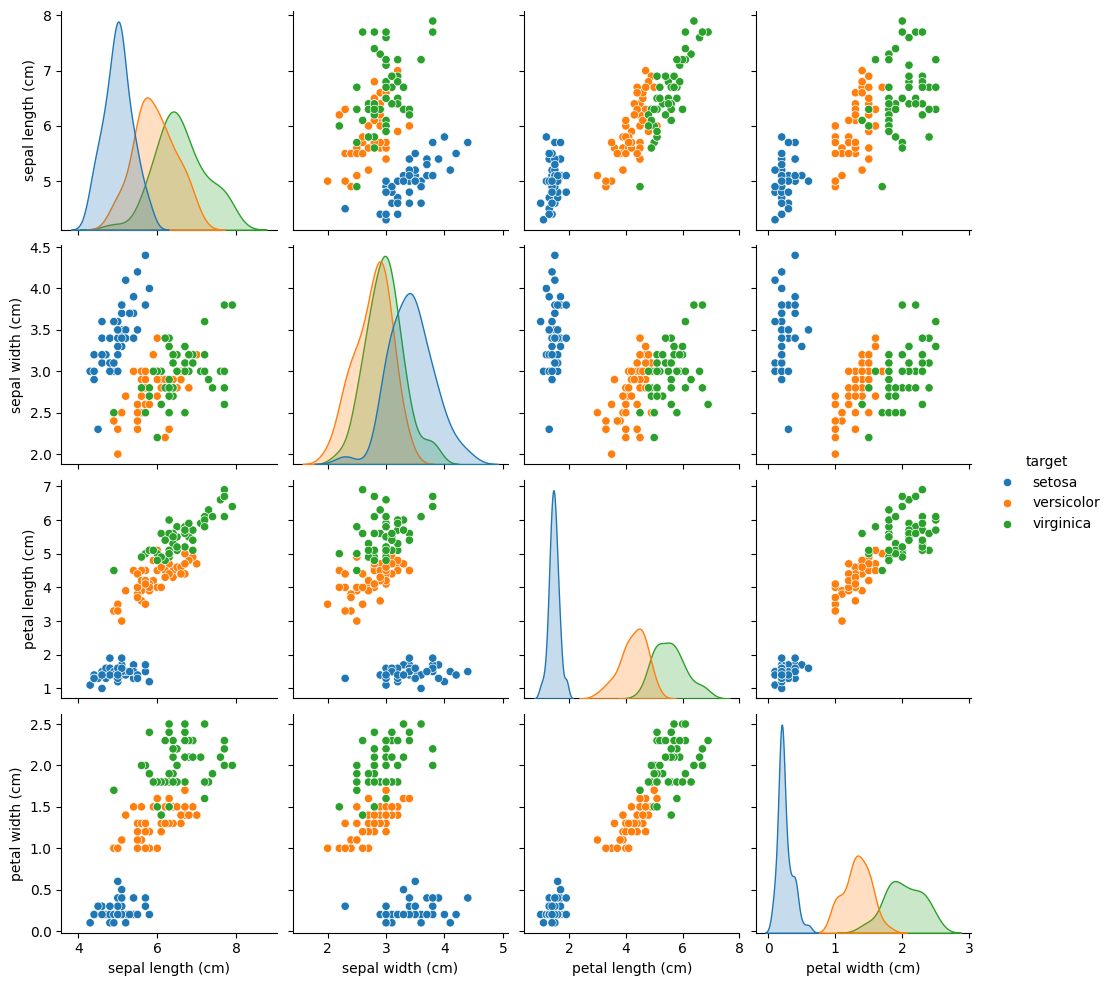

In [10]:
# data visualization
sns.pairplot(iris_df, hue='target')
plt.show()

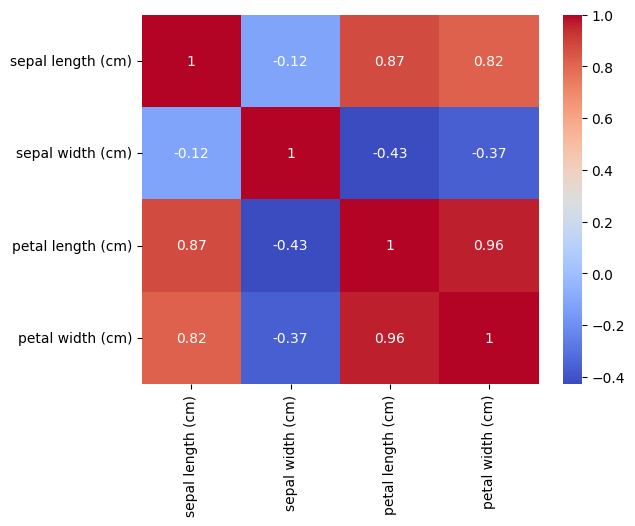

In [12]:
# correlation heatmap
sns.heatmap(iris_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [18]:
# step 5 
# define features and target variable
X = iris_df.drop(['target'], axis=1)
y = iris_df['target']

In [19]:
# step 6 train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("traning data shape: ", X_train.shape)
print("testing data shape: ", X_test.shape)

traning data shape:  (120, 4)
testing data shape:  (30, 4)


In [20]:
# feature scaling (svm)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Transform the test set using the same scaler
X_test = scaler.transform(X_test)

In [21]:
# train the SVM model
model = SVC(kernel='linear', random_state=42)
# train the model
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
# step 9 make predictions
y_pred = model.predict(X_test)

In [23]:
# step 10 
# evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


Accuracy Score: 0.9666666666666667
